In [1]:
import warnings
warnings.simplefilter("ignore")

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, LabelEncoder
from category_encoders import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score,accuracy_score,precision_score, recall_score, average_precision_score, precision_recall_curve, roc_curve, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight

import joblib

# label_encoder object knows how to understand word labels.
label_encoder = preprocessing.LabelEncoder()
scaler = StandardScaler()
from sklearn.compose import ColumnTransformer


%matplotlib inline
np.random.seed(42)

In [2]:
df = pd.read_csv("data/postpartum-depression.csv")

In [3]:
df.head()

,Age,Gestational Age,Number of sons,Number of daughters,Total Number of Children,Gravida,Female Education,Husband Education,Working Status,Physical Health,...,"Feeling down, depressed, or hopeless",Trouble falling or staying sleep or sleeping too much,Feeling tired or having little energy,Poor appetite or overeating,Feeling badabout yourself that you are failure or have let yourself or your family down,"Trouble concentrating on things, such as reading the newspaper or watching television",Moving or speaking so slowly that other people could have Noticed.,"Thoughts that you would be better off dead, or of hurting yourself",Scalling,Labelling
0,25.0,26,0,0,0,Primigravida,Graduation,Graduation,Housewife,Healthy,...,3,1,1,2,2,3,2.0,1.0,16,Depressed
1,28.0,35,0,1,1,Multigravida,Intermediate,Matric,Working Lady,Healthy,...,2,3,0,3,1,2,0.0,1.0,13,Depressed
2,26.0,28,0,0,0,Primigravida,Graduation,Graduation,Housewife,Healthy,...,1,3,2,0,3,3,0.0,0.0,13,Depressed
3,25.0,28,0,1,1,Multigravida,Graduation,Graduation,Housewife,Healthy,...,0,3,3,3,1,3,3.0,0.0,17,Depressed
4,24.0,39,0,0,0,Primigravida,Graduation,Graduation,Housewife,Healthy,...,1,0,1,1,0,0,0.0,0.0,5,Not


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14008 entries, 0 to 14007
Data columns (total 27 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   Age                                                                                      14006 non-null  float64
 1   Gestational Age                                                                          14008 non-null  int64  
 2   Number of sons                                                                           14008 non-null  int64  
 3   Number of daughters                                                                      14008 non-null  int64  
 4   Total Number of Children                                                                 14008 non-null  int64  
 5   Gravida                                                     

# Data Cleaning <a class="anchor" id="data-cleaning"></a>


In [6]:
#check for duplicates
df.duplicated().sum()

7000

In [7]:
df = df.drop_duplicates()
df.duplicated().sum()

0

In [8]:
#check for null values
df.isnull().sum()

Age                                                                                        1
Gestational Age                                                                            0
Number of sons                                                                             0
Number of daughters                                                                        0
Total Number of Children                                                                   0
Gravida                                                                                    0
Female Education                                                                           0
Husband Education                                                                          0
Working Status                                                                             0
Physical Health                                                                            0
Previous Miscarriage                                                  

In [9]:
#drop rows with null values
df = df.dropna()

In [10]:
df.describe()

,Age,Gestational Age,Number of sons,Number of daughters,Total Number of Children,Little interest or pleasure in doing things,"Feeling down, depressed, or hopeless",Trouble falling or staying sleep or sleeping too much,Feeling tired or having little energy,Poor appetite or overeating,Feeling badabout yourself that you are failure or have let yourself or your family down,"Trouble concentrating on things, such as reading the newspaper or watching television",Moving or speaking so slowly that other people could have Noticed.,"Thoughts that you would be better off dead, or of hurting yourself",Scalling
count,6999.000000,6999.000000,6999.000000,6999.000000,6999.000000,6999.000000,6999.000000,6999.000000,6999.000000,6999.000000,6999.000000,6999.000000,6999.000000,6999.000000,6999.000000
mean,28.050293,31.059580,1.063295,1.091299,2.155737,1.392056,1.455351,1.268181,1.071010,1.301900,1.095014,1.199314,1.163452,1.124303,11.070582
std,5.119720,3.838482,1.126277,1.156061,1.470207,1.088680,1.097413,1.108157,1.040183,1.108895,1.075847,1.104497,1.102817,1.149316,3.716349
min,3.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,25.000000,28.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000
50%,28.000000,30.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,11.000000
75%,31.000000,34.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,14.000000
max,46.000000,41.000000,6.000000,6.000000,7.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,24.000000


In [11]:
(df["Age"] < 15).value_counts()

Age
False    6998
True        1
Name: count, dtype: int64

In [12]:
mask = df["Age"] > 15
df = df[mask]

In [13]:
df.describe()

,Age,Gestational Age,Number of sons,Number of daughters,Total Number of Children,Little interest or pleasure in doing things,"Feeling down, depressed, or hopeless",Trouble falling or staying sleep or sleeping too much,Feeling tired or having little energy,Poor appetite or overeating,Feeling badabout yourself that you are failure or have let yourself or your family down,"Trouble concentrating on things, such as reading the newspaper or watching television",Moving or speaking so slowly that other people could have Noticed.,"Thoughts that you would be better off dead, or of hurting yourself",Scalling
count,6998.000000,6998.000000,6998.000000,6998.000000,6998.000000,6998.000000,6998.000000,6998.000000,6998.000000,6998.000000,6998.000000,6998.000000,6998.000000,6998.000000,6998.000000
mean,28.053873,31.058588,1.063304,1.091026,2.155473,1.391826,1.455273,1.268077,1.071163,1.301801,1.095170,1.199486,1.163332,1.124035,11.070163
std,5.111319,3.837860,1.126357,1.155918,1.470147,1.088588,1.097472,1.108201,1.040179,1.108943,1.075844,1.104483,1.102851,1.149180,3.716450
min,18.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,25.000000,28.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000
50%,28.000000,30.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,11.000000
75%,31.000000,34.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,14.000000
max,46.000000,41.000000,6.000000,6.000000,7.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,24.000000


In [14]:
df.select_dtypes("object").describe()

,Gravida,Female Education,Husband Education,Working Status,Physical Health,Previous Miscarriage,Sufficient Money for Basic Needs,Current Appereance Acceptance,Family System,Male Gender Preference,Relationship with Mother in-law,Labelling
count,6998,6998,6998,6998,6998,6998,6998,6998,6998,6998,6998,6998
unique,3,8,8,3,2,4,4,5,2,4,3,2
top,Multigravida,Matric,Matric,Housewife,Healthy,No,No,No,Joint,Yes,Poor,Depressed
freq,5175,1968,1826,5177,6928,4256,3082,3258,4673,3127,4511,4536


In [15]:
df["Labelling"] = df["Labelling"].str.strip()
df["Labelling"].unique()


array(['Depressed', 'Not'], dtype=object)

In [16]:
df["Gravida"] = df["Gravida"].str.split("+").str[0]
df["Gravida"].unique()


array(['Primigravida', 'Multigravida'], dtype=object)

In [17]:
df["Female Education"] = df["Female Education"].str.strip()
df["Female Education"].unique()


array(['Graduation', 'Intermediate', 'Middle', 'Matric', 'Primary',
       'Uneducated'], dtype=object)

In [18]:
df["Husband Education"] = df["Husband Education"].str.strip()
df["Husband Education"].unique()


array(['Graduation', 'Matric', 'Intermediate', 'Uneducated', 'Primary',
       'Middle'], dtype=object)

In [19]:
df["Working Status"] = df["Working Status"].str.strip()
df["Working Status"].unique()


array(['Housewife', 'Working Lady'], dtype=object)

In [20]:
df["Male Gender Preference"] = df["Male Gender Preference"].str.replace(" ", "", regex=False)


In [21]:
df["Current Appereance Acceptance"].unique()
df["Current Appereance Acceptance"] = df["Current Appereance Acceptance"].str.replace(" ", "", regex=False)
df["Current Appereance Acceptance"] = df["Current Appereance Acceptance"].str.replace("YY", "Yes", regex=False)
df["Current Appereance Acceptance"].unique()


array(['Yes', 'No'], dtype=object)

In [22]:
df["Previous Miscarriage"] = df["Previous Miscarriage"].str.replace(" ", "", regex=False)
df["Previous Miscarriage"].unique()

array(['No', 'Yes'], dtype=object)

In [23]:
df["Sufficient Money for Basic Needs"] = df["Sufficient Money for Basic Needs"].str.replace(" ", "", regex=False)
df["Sufficient Money for Basic Needs"].unique()

array(['Yes', 'No'], dtype=object)

In [24]:
df.select_dtypes("object").describe()

,Gravida,Female Education,Husband Education,Working Status,Physical Health,Previous Miscarriage,Sufficient Money for Basic Needs,Current Appereance Acceptance,Family System,Male Gender Preference,Relationship with Mother in-law,Labelling
count,6998,6998,6998,6998,6998,6998,6998,6998,6998,6998,6998,6998
unique,2,6,6,2,2,2,2,2,2,2,3,2
top,Multigravida,Matric,Matric,Housewife,Healthy,No,No,No,Joint,No,Poor,Depressed
freq,5176,1968,1826,5177,6928,4743,3570,3592,4673,3501,4511,4536


In [25]:
num_cols = [
    "Age",
    "Gestational Age",
    "Number of sons ",
    "Number of daughters",
    "Total Number of Children",
]


In [26]:
cat_cols = [
    "Gravida",
    "Female Education",
    "Husband Education",
    "Working Status",
    "Physical Health ",
    "Previous Miscarriage",
    "Sufficient Money for Basic Needs",
    "Current Appereance Acceptance",
    "Family System",
    "Male Gender Preference",
    "Relationship with Mother in-law",
    "Little interest or pleasure in doing things",
    "Feeling down, depressed, or hopeless",
    "Trouble falling or staying sleep or sleeping too much",
    "Feeling tired or having little energy",
    "Poor appetite or overeating",
    "Thoughts that you would be better off dead, or of hurting yourself",
    "Feeling badabout yourself that you are failure or have let yourself or your family down",
    "Trouble concentrating on things, such as reading the newspaper or watching television "
]


# Exploratory Data Analysis <a class="anchor" id="EDA"></a>


## Univariant Analysis <a class="anchor" id="univariant"></a>


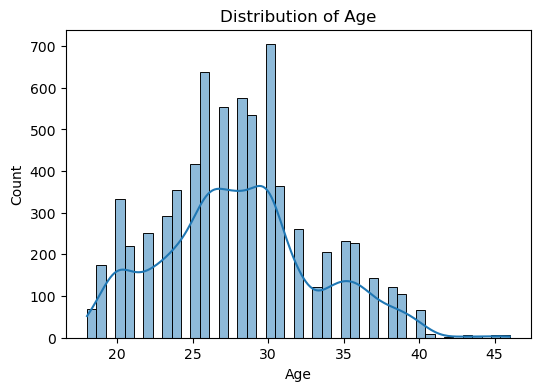

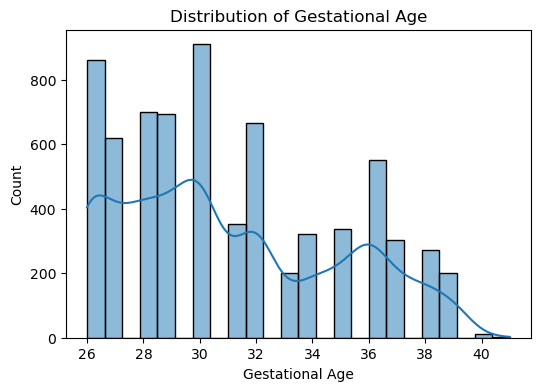

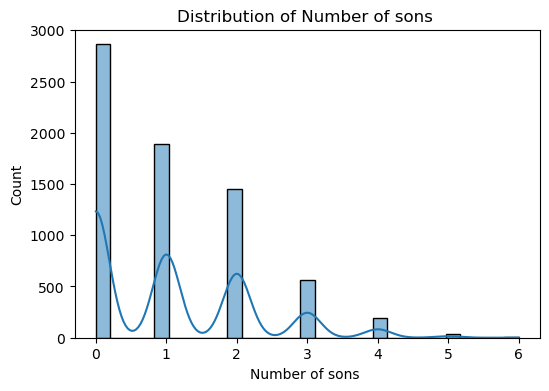

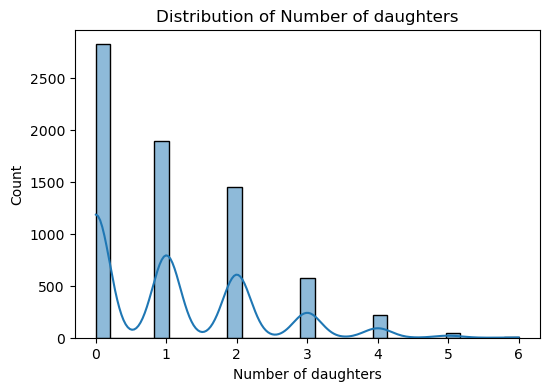

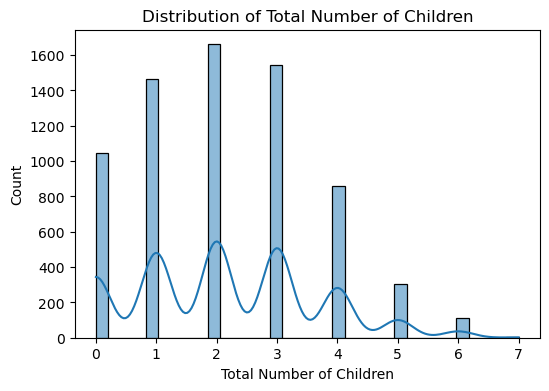

In [29]:
#Distribution of all nurical clomns
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


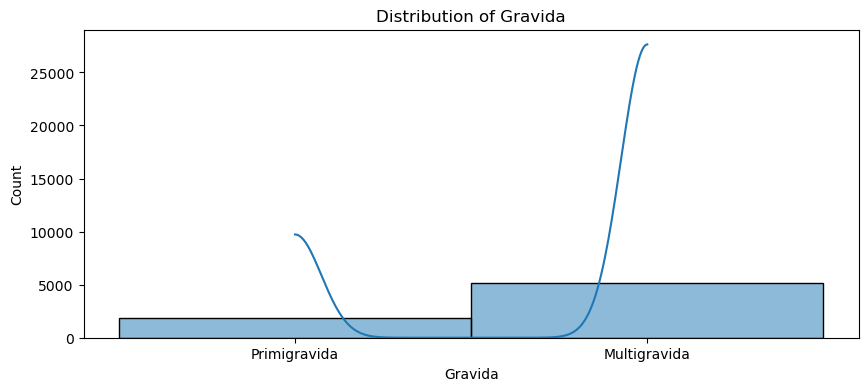

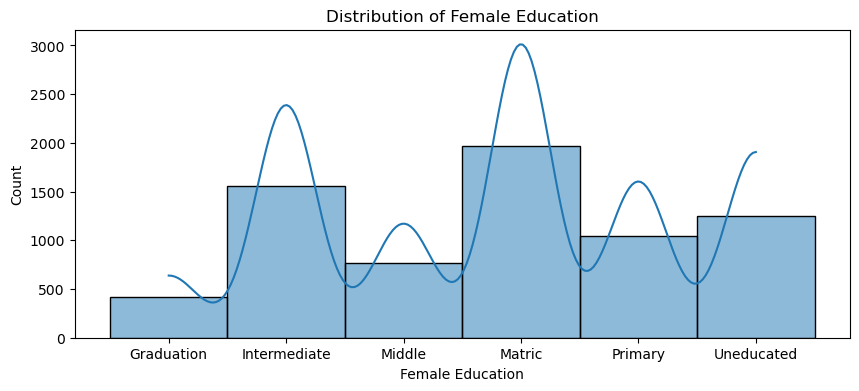

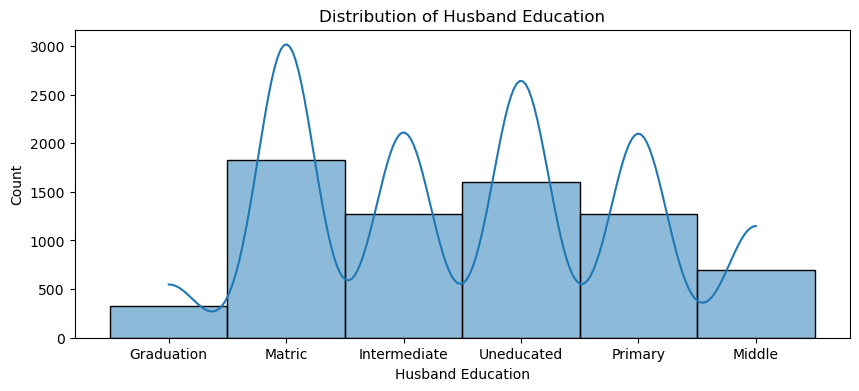

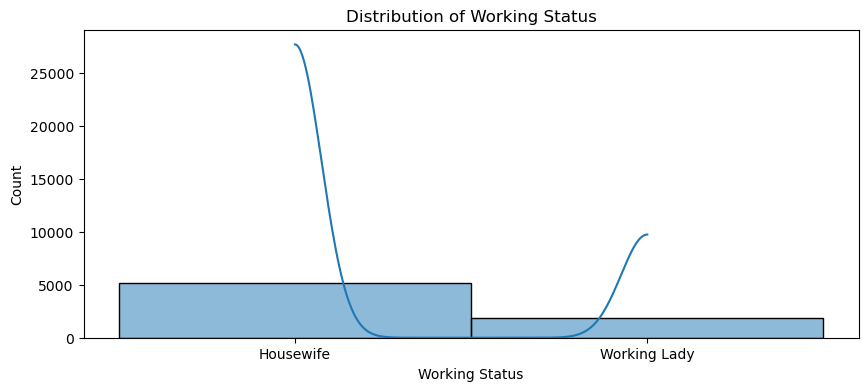

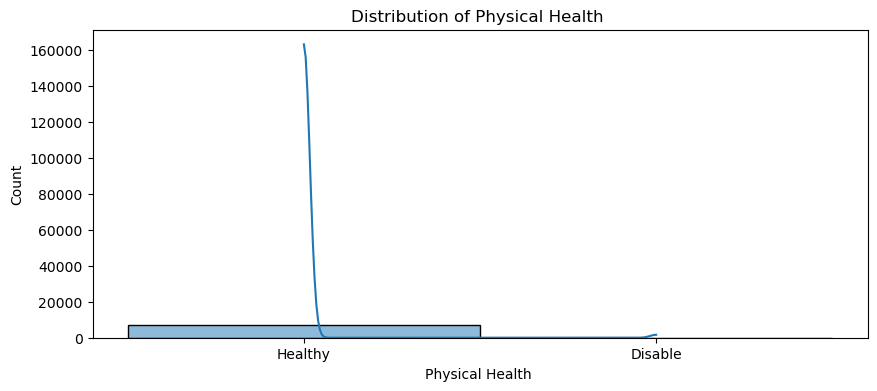

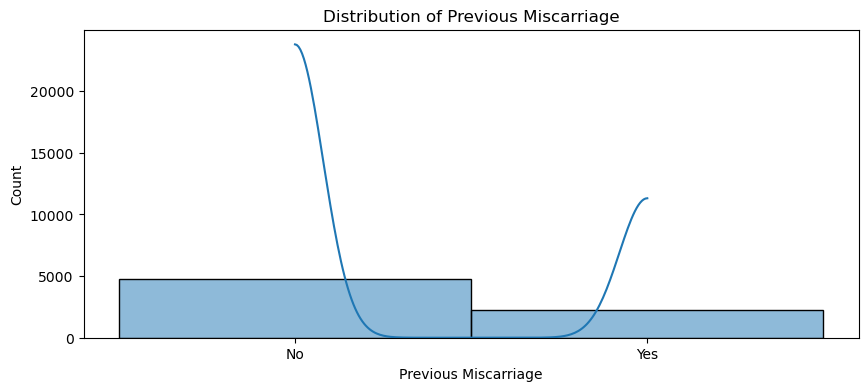

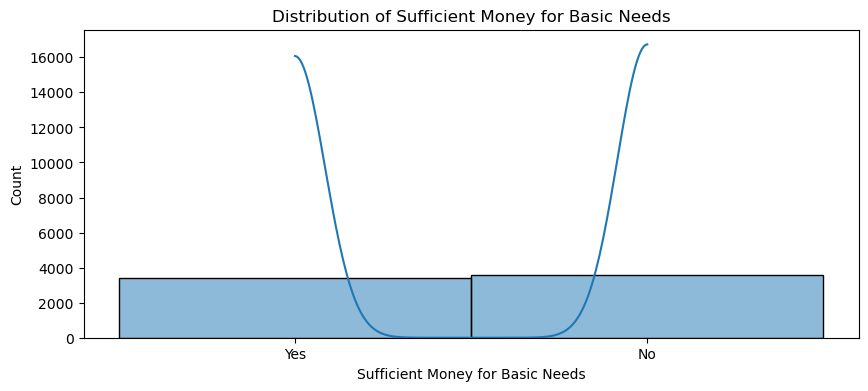

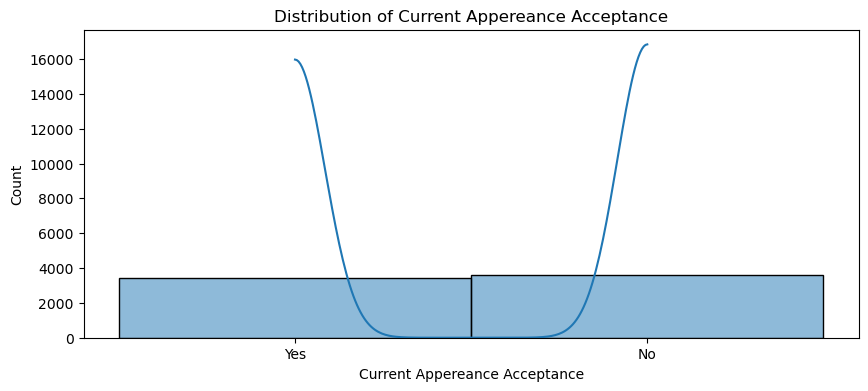

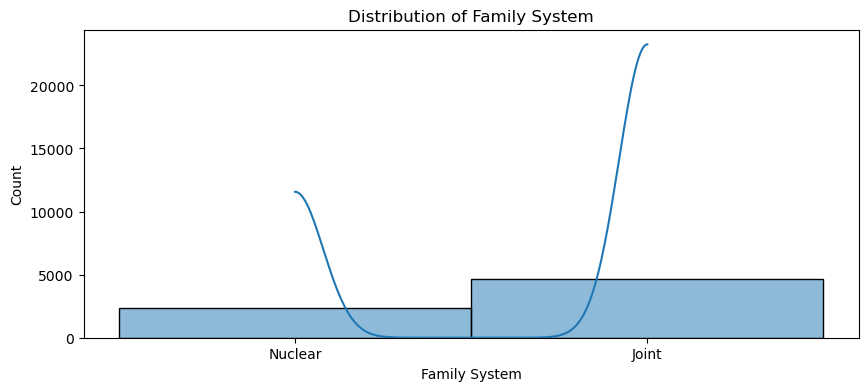

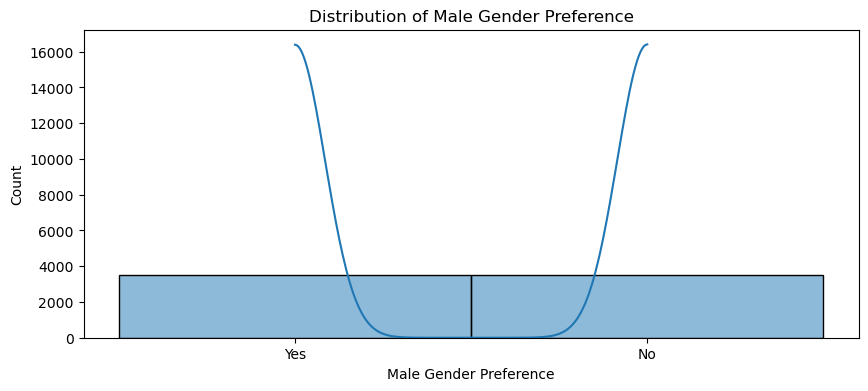

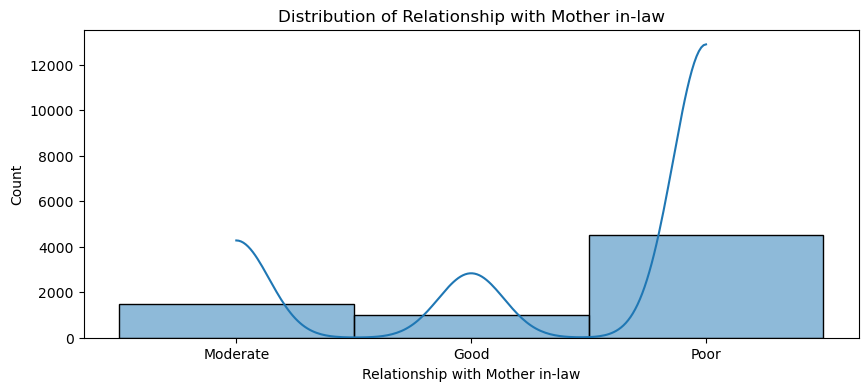

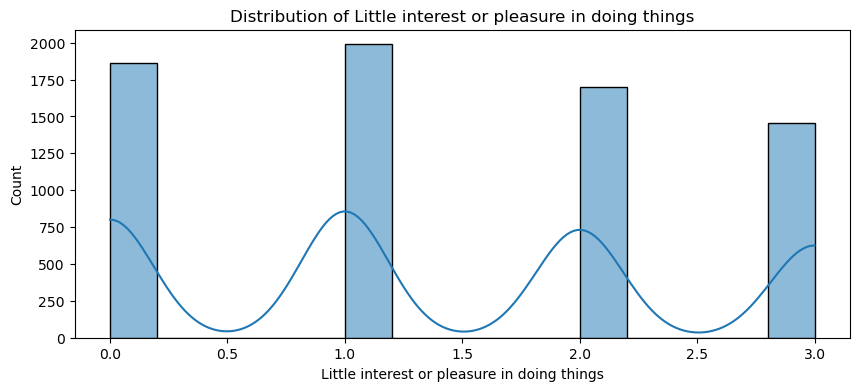

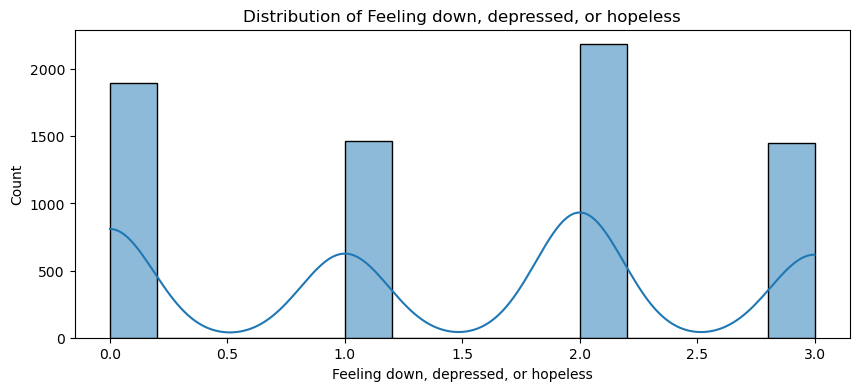

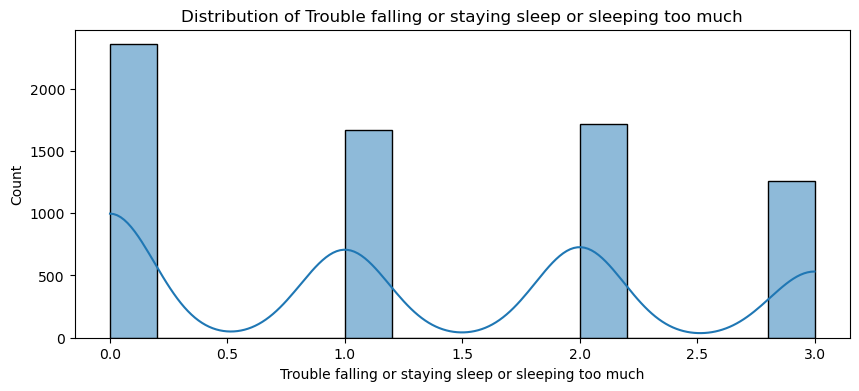

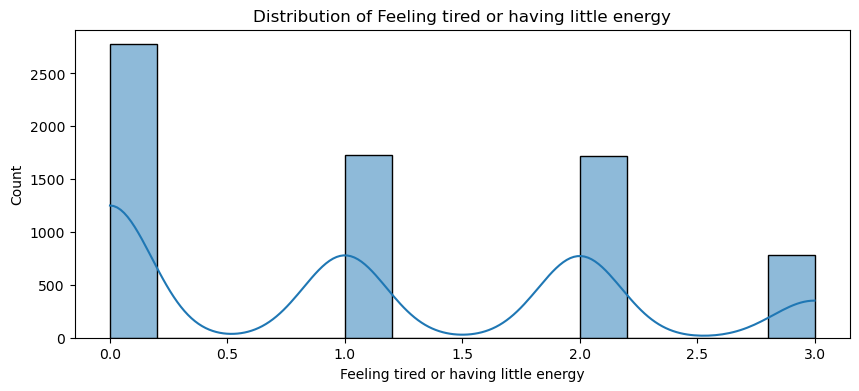

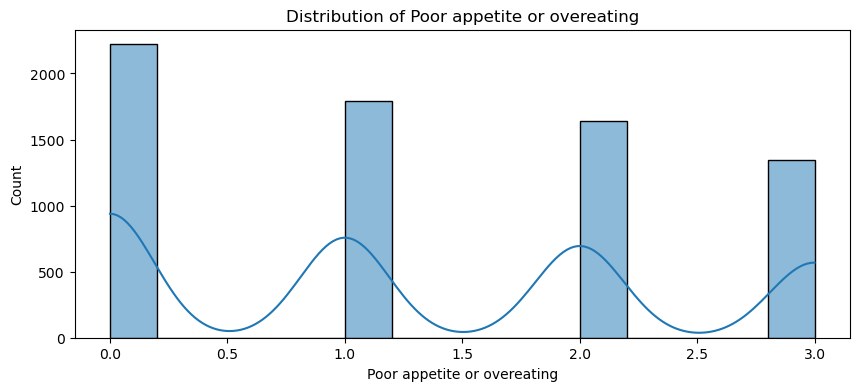

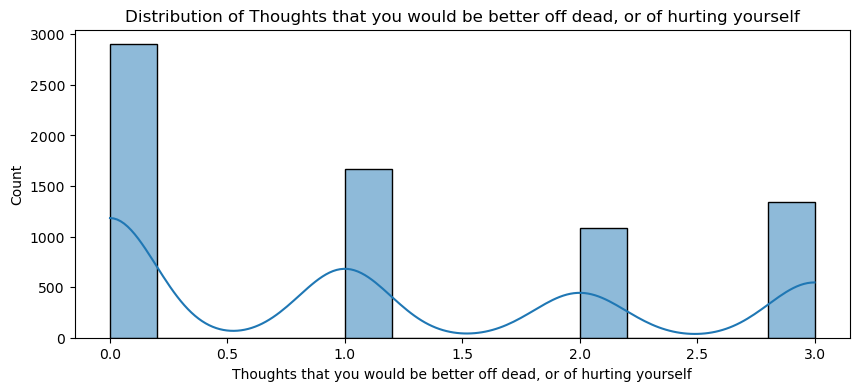

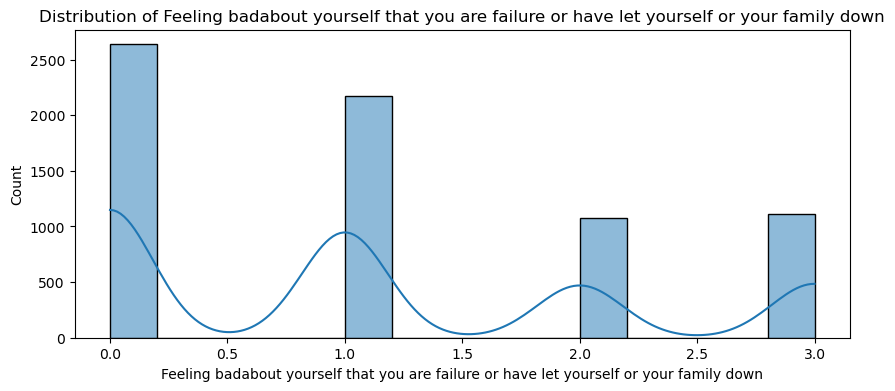

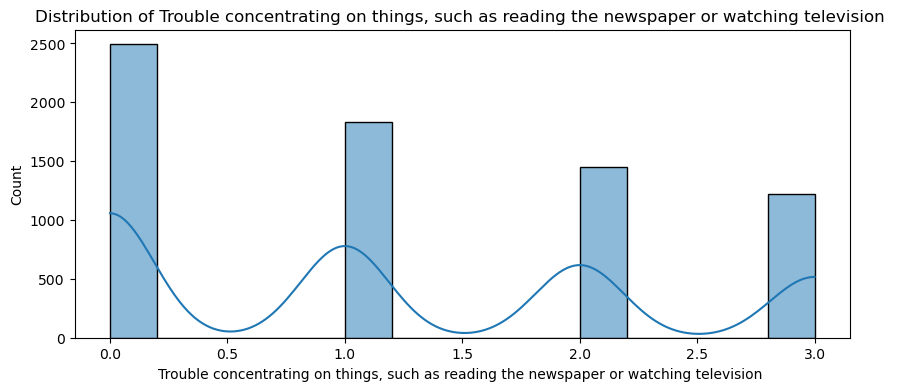

In [30]:
#Distribution of all nurical clomns
for col in cat_cols:
    plt.figure(figsize=(10,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


## Bivariant Analysis <a class="anchor" id="bivariant"></a>


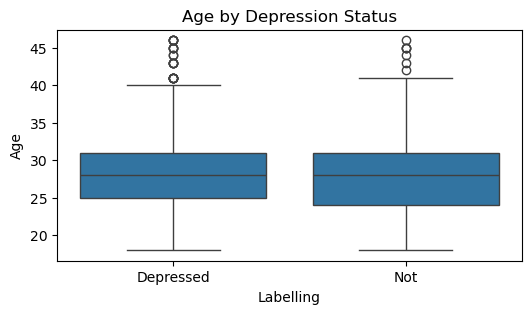

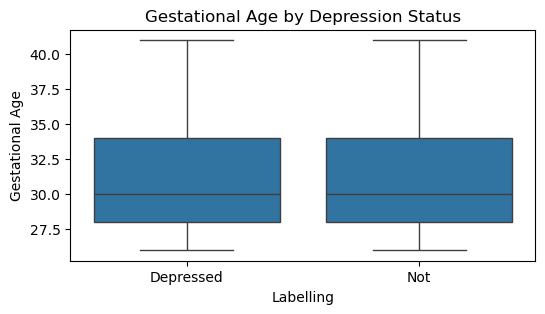

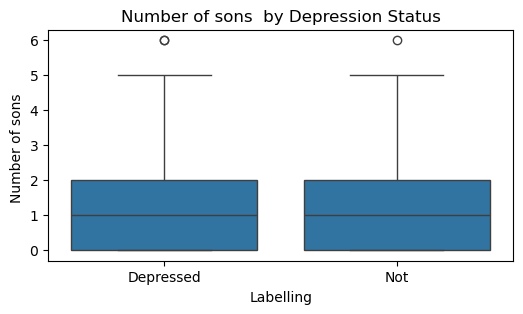

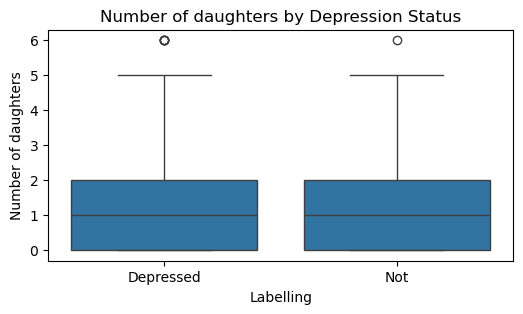

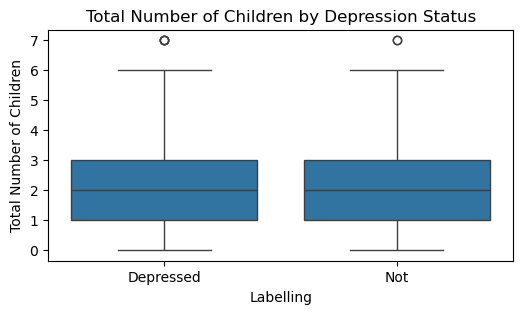

In [32]:
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x='Labelling', y=col, data=df)
    plt.title(f'{col} by Depression Status')
    plt.show()


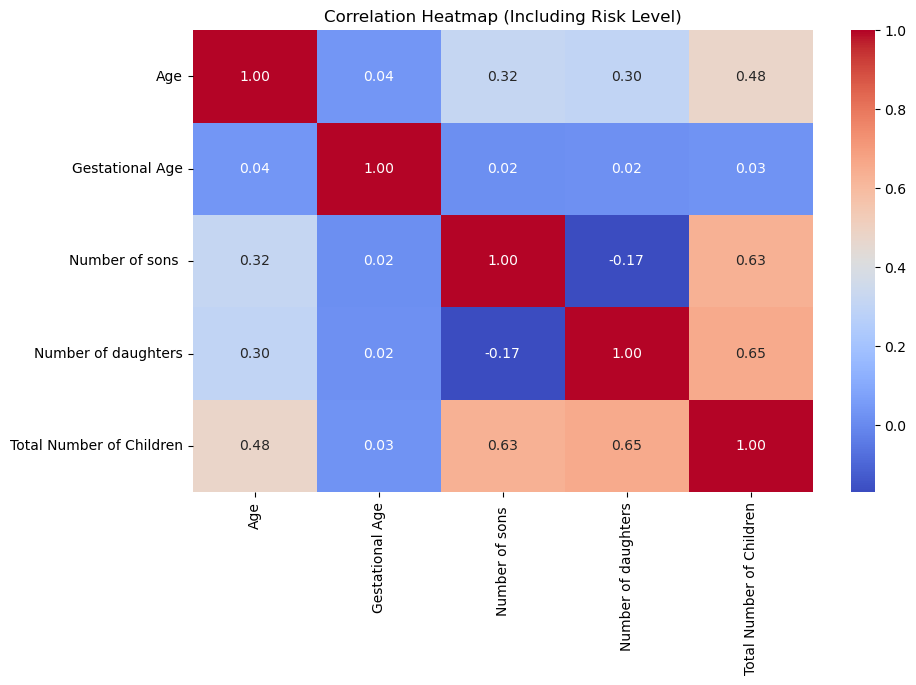

In [33]:
#correlation Heatmap
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Including Risk Level)")
plt.show()


### Class Balance <a class="anchor" id="classbalance"></a>


In [35]:
df["Labelling"].value_counts(normalize=True) *100

Labelling
Depressed    64.81852
Not          35.18148
Name: proportion, dtype: float64

# Modeling <a class="anchor" id="modeling"></a>


In [37]:
features = [
    "Age",
    "Number of sons ",
    "Number of daughters",
    "Gravida",
    "Female Education",
    "Husband Education",
    "Working Status",
    "Physical Health ",
    "Previous Miscarriage",
    "Sufficient Money for Basic Needs",
    "Current Appereance Acceptance",
    "Family System",
    "Male Gender Preference",
    "Relationship with Mother in-law",
    "Little interest or pleasure in doing things",
    "Trouble falling or staying sleep or sleeping too much",
    "Feeling tired or having little energy",
    "Poor appetite or overeating",
    "Trouble concentrating on things, such as reading the newspaper or watching television ",
    "Feeling badabout yourself that you are failure or have let yourself or your family down",
    "Thoughts that you would be better off dead, or of hurting yourself",
    "Feeling down, depressed, or hopeless"


]


In [38]:
df[features].head()

,Age,Number of sons,Number of daughters,Gravida,Female Education,Husband Education,Working Status,Physical Health,Previous Miscarriage,Sufficient Money for Basic Needs,...,Male Gender Preference,Relationship with Mother in-law,Little interest or pleasure in doing things,Trouble falling or staying sleep or sleeping too much,Feeling tired or having little energy,Poor appetite or overeating,"Trouble concentrating on things, such as reading the newspaper or watching television",Feeling badabout yourself that you are failure or have let yourself or your family down,"Thoughts that you would be better off dead, or of hurting yourself","Feeling down, depressed, or hopeless"
0,25.0,0,0,Primigravida,Graduation,Graduation,Housewife,Healthy,No,Yes,...,Yes,Moderate,1,1,1,2,3,2,1.0,3
1,28.0,0,1,Multigravida,Intermediate,Matric,Working Lady,Healthy,No,Yes,...,Yes,Good,1,3,0,3,2,1,1.0,2
2,26.0,0,0,Primigravida,Graduation,Graduation,Housewife,Healthy,No,Yes,...,Yes,Poor,1,3,2,0,3,3,0.0,1
3,25.0,0,1,Multigravida,Graduation,Graduation,Housewife,Healthy,No,Yes,...,Yes,Poor,1,3,3,3,3,1,0.0,0
4,24.0,0,0,Primigravida,Graduation,Graduation,Housewife,Healthy,No,Yes,...,Yes,Good,2,0,1,1,0,0,0.0,1


In [39]:
target= "Labelling"
X= df[features]
y = df[target]

print(X.shape)
print(y.shape)

(6998, 22)
(6998,)


In [40]:
y = y.map({'Not': 0, 'Depressed': 1})


In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_test.shape)
print(y_test.shape)
y.head()

(1400, 22)
(1400,)


0    1
1    1
2    1
3    1
4    0
Name: Labelling, dtype: int64

## Logistic Regression Model <a class="anchor" id="lr-model"></a>


In [43]:
lr_model = make_pipeline(
    OneHotEncoder(),
    LogisticRegression(max_iter=1000, class_weight='balanced')
)


In [44]:
 #Create k-Fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Conduct k-fold cross-validation
cv_lr = cross_val_score(lr_model, # Model
                        X_train, # Feature matrix
                        y_train, # Target vector
                        cv=skf, # Performance metric
                        scoring="accuracy" # Loss function
                        ) 

cv_lr
print("Logistic Regression CV Accuracy on training set:", np.mean(cv_lr), "±", np.std(cv_lr))


Logistic Regression CV Accuracy on training set: 0.9006786990935784 ± 0.0055203220286091535


## Random forest Model  <a class="anchor" id="rf-model"></a>


In [46]:
rf_model = make_pipeline(
    OrdinalEncoder(),
    RandomForestClassifier(class_weight="balanced", random_state=42)
)


In [47]:
# Conduct k-fold cross-validation
cv_rf = cross_val_score(rf_model, # Model
                        X_train, # Feature matrix
                        y_train, # Target vector
                        cv=skf, # Performance metric
                        scoring="accuracy" # Loss function
                        ) 

cv_rf
print("Logistic Regression CV Accuracy on training set:", np.mean(cv_rf), "±", np.std(cv_rf))


Logistic Regression CV Accuracy on training set: 0.8872844057193923 ± 0.00957210160784666


## Gradient Boosting Model <a class="anchor" id="gb-model"></a>


In [49]:
gb_model = make_pipeline(
    OrdinalEncoder(),
    GradientBoostingClassifier(random_state=42)
)


In [50]:
# Conduct k-fold cross-validation
cv_gb = cross_val_score(gb_model, # Model
                        X_train, # Feature matrix
                        y_train, # Target vector
                        cv=skf, # Performance metric
                        scoring="accuracy" # Loss function
                        ) 

print(cv_gb)
print("Random Forest CV Accuracy on training set:", np.mean(cv_gb), "±", np.std(cv_gb))


[0.88928571 0.89107143 0.89732143 0.90527256 0.89365505]
Random Forest CV Accuracy on training set: 0.8953212370739181 ± 0.005662054029564561


## Setting Hyperparameters for GridSearchCV <a class="anchor" id="Performance"></a>


In [52]:

param_grid = {
    'gradientboostingclassifier__n_estimators': [100, 200, 300],
    'gradientboostingclassifier__learning_rate': [0.01, 0.05, 0.1],
    'gradientboostingclassifier__max_depth': [3, 4, 5],
    'gradientboostingclassifier__subsample': [0.8, 1.0]
}
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_gb = GridSearchCV(
    gb_model,  # your pipeline
    param_grid,
    cv= kfold,
    scoring='accuracy',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)
print("Best Parameters:", grid_gb.best_params_)
print("Best CV Accuracy:", grid_gb.best_score_)

Best Parameters: {'gradientboostingclassifier__learning_rate': 0.1, 'gradientboostingclassifier__max_depth': 3, 'gradientboostingclassifier__n_estimators': 300, 'gradientboostingclassifier__subsample': 1.0}
Best CV Accuracy: 0.9040741095365761


## Testing the best Model <a class="anchor" id="Test"></a>


In [54]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)


In [65]:
Model_best = make_pipeline(
    OneHotEncoder(),
    GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=42, subsample=1.0)
)
model = Model_best.fit(
    X_train,
    y_train,
    gradientboostingclassifier__sample_weight=sample_weights
)


In [67]:
# -------------------------------
# Predict
# -------------------------------
y_pred = model.predict(X_test)

# Get probability for the positive class (1 = 'Depressed')
y_prob = model.predict_proba(X_test)[:, 1]

# -------------------------------
# Compute metrics
# -------------------------------
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
    'Recall (macro)': recall_score(y_test, y_pred, average='macro'),
    'F1 Score (macro)': f1_score(y_test, y_pred, average='macro'),
    'ROC-AUC': roc_auc_score(y_test, y_prob),
    'Average Precision': average_precision_score(y_test, y_prob)
}

# -------------------------------
# Convert to table
# -------------------------------
import pandas as pd

metrics_table = pd.DataFrame(metrics, index=[0]).T
metrics_table.columns = ['Score']

print(metrics_table)


                      Score
Accuracy           0.905714
Precision (macro)  0.891859
Recall (macro)     0.903963
F1 Score (macro)   0.897242
ROC-AUC            0.974261
Average Precision  0.987244


## Result Communication <a class="anchor" id="result"></a>


In [70]:
label_map = {0: 'Not Depressed', 1: 'Depressed'}

# Map numeric labels to strings
actual_labels = y_test.reset_index(drop=True).map(label_map)  # if Region_Target_test is a pandas Series
pred_labels = pd.Series(y_pred).map(label_map)

results_df = pd.DataFrame({
    'Actual': actual_labels,
    'Predicted': pred_labels,
    'Probability_High': y_prob

})

# Display first few rows
print(results_df.head(20))


           Actual      Predicted  Probability_High
0       Depressed      Depressed          0.796731
1       Depressed  Not Depressed          0.384933
2       Depressed      Depressed          0.999877
3       Depressed      Depressed          0.999991
4       Depressed      Depressed          0.907489
5   Not Depressed  Not Depressed          0.334635
6   Not Depressed  Not Depressed          0.225640
7       Depressed      Depressed          0.996583
8       Depressed      Depressed          0.930009
9       Depressed      Depressed          0.994459
10  Not Depressed  Not Depressed          0.129786
11      Depressed      Depressed          0.999980
12      Depressed      Depressed          0.738798
13  Not Depressed  Not Depressed          0.174038
14      Depressed      Depressed          0.834411
15      Depressed      Depressed          0.807263
16      Depressed  Not Depressed          0.039352
17      Depressed      Depressed          0.577109
18  Not Depressed  Not Depresse

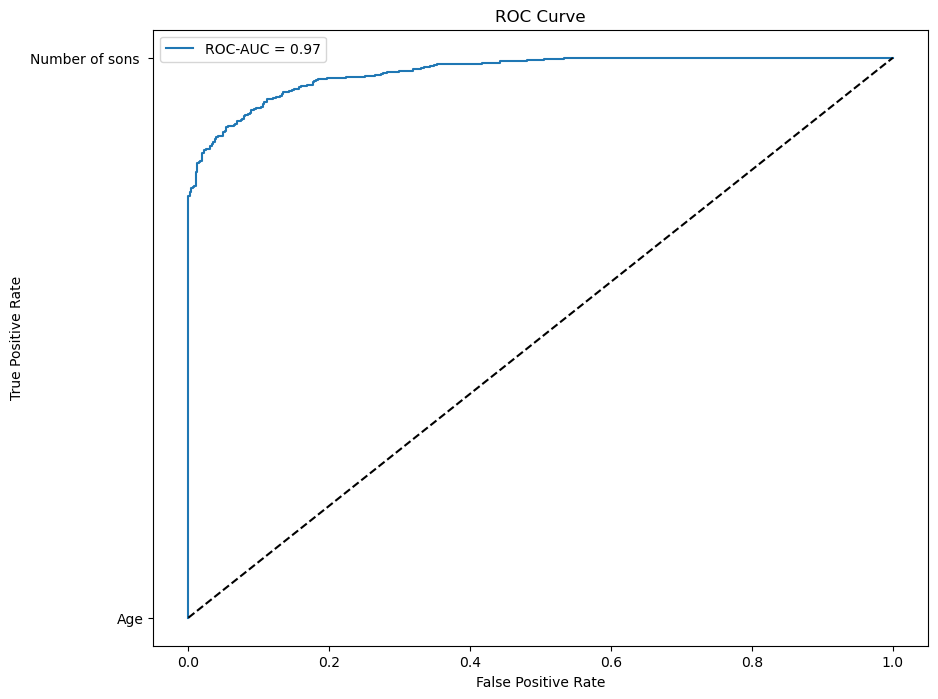

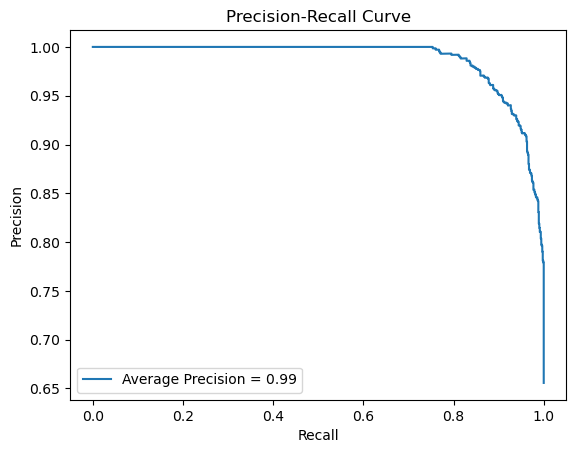

In [72]:


# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_prob):.2f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision, label=f'Average Precision = {average_precision_score(y_test, y_prob):.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


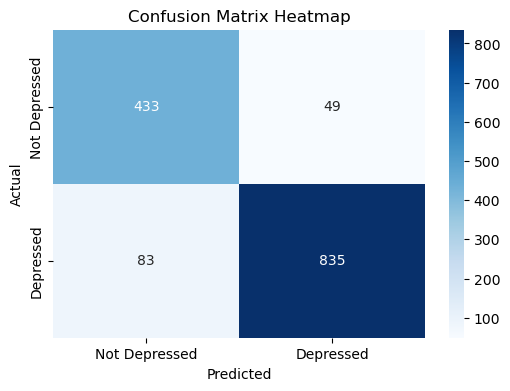

In [74]:
cm = confusion_matrix(y_test, y_pred)

# Labels for axes
labels = ['Not Depressed', 'Depressed']  # your binary classes

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

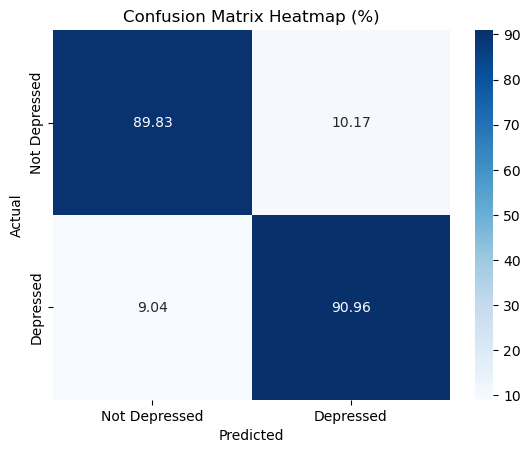

In [76]:
cm_norm = (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]) * 100
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap (%)')
plt.show()

In [83]:
joblib.dump(model, "depression_status_model.pkl")

['depression_status_model.pkl']